Parameter_Space_Figure4

In [1]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

In [3]:
higherordermortality_init = np.linspace(0.01,0.03, 100)
higherordermortality_range = [np.array([0, 0, 0, val]) for val in higherordermortality_init]
GGE_range = np.linspace(0.3,0.4, 100)

In [4]:
N0_val_range = np.linspace(0.002,0.0055, 100)

In [5]:
def plot_stability_heatmap(ds, title='Model Stability across Parameter Space'):
    """
    Plot stability heatmap from stability scan results
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Output from stability scan containing 'stability' variable
    title : str
        Title for the plot
    """
    def stability_to_numeric(data):
        """Convert stability strings to numeric values"""
        stability_num = xr.full_like(data['stability'], np.nan, dtype=float)
        stability_num = stability_num.where(data['stability'] != 'stable', 1)
        stability_num = stability_num.where(data['stability'] != 'unstable', -1)
        stability_num = stability_num.where(data['stability'] != 'marginally_stable', 0)
        # NaN values remain as NaN (failed convergence)
        return stability_num
    
    # Create the heatmap
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Convert stability to numeric
    stability_numeric = stability_to_numeric(ds)
    
    # Create the heatmap
    im = ax.pcolormesh(
        ds['GGE__gge'], 
        ds['HigherOrderMortality__rate'],
        stability_numeric.T,
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        shading='nearest'
    )
    
    # Add colorbar with custom labels
    cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1])
    cbar.ax.set_yticklabels(['Unstable', 'Marginally\nStable', 'Stable'])
    
    # Labels and title
    ax.set_xlabel('Gross Growth Efficiency')
    ax.set_ylabel('Higher Order Mortality')
    ax.set_title(title)
    
    # Add grid for clarity
    ax.set_xticks(ds['GGE__gge'])
    ax.set_yticks(ds['HigherOrderMortality__rate'])
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Let's check IVP solver results to find stable runs and check those against this!

In [ ]:
ivp_result_lowNuts_HOMvsGGE = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp_lowNuts', 
    param_name='HigherOrderMortality__rate',
    param_values=higherordermortality_range,       
    param_name2='GGE__gge',
    param_values2=GGE_range,     
    processes=20
)

PROGRESS: Completed 44/100 outer points. (HigherOrderMortality__rate = [0.         0.         0.         0.01868687]).


In [ ]:
ivp_result_highNuts_HOMvsGGE = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp_highNuts', 
    param_name='HigherOrderMortality__rate',
    param_values=higherordermortality_range,       
    param_name2='GGE__gge',
    param_values2=GGE_range,     
    processes=20
)

In [ ]:
ivp_result_lowHOM_NutsvsGGE = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp_lowHOM', 
    param_name='N0__value',
    param_values=N0_val_range,       
    param_name2='GGE__gge',
    param_values2=GGE_range,    
    processes=20
)

In [ ]:
ivp_result_highHOM_NutsvsGGE = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp_highHOM', 
    param_name='N0__value',
    param_values=N0_val_range,       
    param_name2='GGE__gge',
    param_values2=GGE_range,     
    processes=20
)

In [ ]:
ivp_result_lowGGE_NutsvsHOM = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp_lowGGE', 
    param_name='N0__value',
    param_values=N0_val_range,       
    param_name2='HigherOrderMortality__rate',
    param_values2=higherordermortality_range,     
    processes=20
)

In [ ]:
ivp_result_highGGE_NutsvsHOM = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp_highGGE', 
    param_name='N0__value',
    param_values=N0_val_range,       
    param_name2='HigherOrderMortality__rate',
    param_values2=higherordermortality_range,     
    processes=20
)

In [ ]:
ivp_result_lowNuts_HOMvsGGE

In [ ]:
# SAVE OUTPUT FOR LATER:

ivp_result_lowNuts_HOMvsGGE.to_netcdf("OutputScans/ivp_result_lowNuts_HOMvsGGE.ncdf", engine='h5netcdf', invalid_netcdf=True)
ivp_result_highNuts_HOMvsGGE.to_netcdf("OutputScans/ivp_result_highNuts_HOMvsGGE.ncdf", engine='h5netcdf', invalid_netcdf=True)

ivp_result_lowHOM_NutsvsGGE.to_netcdf("OutputScans/ivp_result_lowHOM_NutsvsGGE.ncdf", engine='h5netcdf', invalid_netcdf=True)
ivp_result_highHOM_NutsvsGGE.to_netcdf("OutputScans/ivp_result_highHOM_NutsvsGGE.ncdf", engine='h5netcdf', invalid_netcdf=True)

ivp_result_lowGGE_NutsvsHOM.to_netcdf("OutputScans/ivp_result_lowGGE_NutsvsHOM.ncdf", engine='h5netcdf', invalid_netcdf=True)
ivp_result_highGGE_NutsvsHOM.to_netcdf("OutputScans/ivp_result_highGGE_NutsvsHOM.ncdf", engine='h5netcdf', invalid_netcdf=True)

In [5]:
import xarray as xr

# LOAD SAVED OUTPUT:

# You may need to use xr.open_dataarray() instead if the original objects were DataArrays
ivp_result_lowNuts_HOMvsGGE = xr.open_dataset("OutputScans/ivp_result_lowNuts_HOMvsGGE.ncdf", engine='h5netcdf')
ivp_result_highNuts_HOMvsGGE = xr.open_dataset("OutputScans/ivp_result_highNuts_HOMvsGGE.ncdf", engine='h5netcdf')

ivp_result_lowHOM_NutsvsGGE = xr.open_dataset("OutputScans/ivp_result_lowHOM_NutsvsGGE.ncdf", engine='h5netcdf')
ivp_result_highHOM_NutsvsGGE = xr.open_dataset("OutputScans/ivp_result_highHOM_NutsvsGGE.ncdf", engine='h5netcdf')

ivp_result_lowGGE_NutsvsHOM = xr.open_dataset("OutputScans/ivp_result_lowGGE_NutsvsHOM.ncdf", engine='h5netcdf')
ivp_result_highGGE_NutsvsHOM = xr.open_dataset("OutputScans/ivp_result_highGGE_NutsvsHOM.ncdf", engine='h5netcdf')

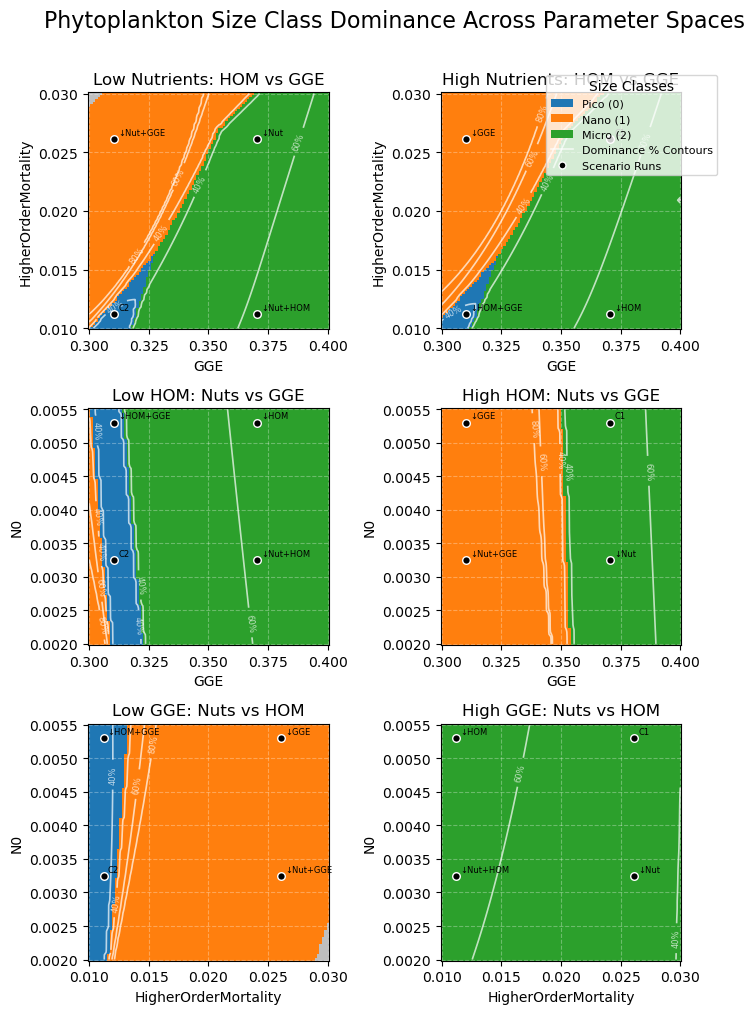

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- Configuration and Class Definition ---

# Define the global color palette and colormap once
PALETTE = sns.color_palette()
COLORS = [PALETTE[0], PALETTE[1], PALETTE[2]] # Blue, Orange, Green (0: Pico, 1: Nano, 2: Micro)
CMAP = ListedColormap(COLORS)
CMAP.set_bad(color='grey', alpha=0.5)

class PhytoplanktonPlotter:
    """
    Handles the calculation and plotting of phytoplankton size class dominance 
    for a single parameter scan (ivp_results).
    """
    def __init__(self, ivp_results, sigma=0.5, contour_levels=[0.4, 0.6, 0.8]):
        """Initialize with data and plotting parameters."""
        self.ivp_results = ivp_results
        self.sigma = sigma
        self.contour_levels = contour_levels
        
        # Data calculated during processing
        self.dominant_class = None
        self.x_coord = None
        self.y_coord = None
        self.X = None
        self.Y = None
        self._calculate_dominance()

    def _get_coords(self):
        """Identify parameter coordinates based on xarray Dataset structure."""
        coord_names = [c for c in self.ivp_results.coords.keys()
                       if c not in ['time', 'phyto', 'zoo', 'clock', 'full']]
        
        if len(coord_names) < 2:
            raise ValueError(f"Could not identify parameter coordinates. Found: {coord_names}")
            
        return coord_names[0], coord_names[1]

    def _calculate_dominance(self):
        """Calculate dominant size class (0, 1, or 2) and dominance strength."""
        
        # 1. Identify coordinates
        self.x_coord, self.y_coord = self._get_coords()
        
        # 2. Extract and average biomass
        # Assuming 'Phytoplankton__biomass' has dimensions (param1, param2, time, phyto)
        phyto_last1000 = self.ivp_results['Phytoplankton__biomass'].isel(time=slice(-1000, None))
        phyto_mean = phyto_last1000.mean(dim='time')
        
        # 3. Setup result arrays
        x_len = len(self.ivp_results[self.x_coord])
        y_len = len(self.ivp_results[self.y_coord])
        
        self.dominant_class = np.full((x_len, y_len), np.nan)
        self.dominance_fields = {
            0: np.full_like(self.dominant_class, np.nan), # Pico
            1: np.full_like(self.dominant_class, np.nan), # Nano
            2: np.full_like(self.dominant_class, np.nan)  # Micro
        }
        
        # 4. Loop and calculate
        for i in range(x_len):
            for j in range(y_len):
                # Note: The original code assumes order (x_coord, y_coord, phyto) for phyto_mean.
                # If your xarray dimensions are different, this indexing must be adjusted.
                biomass_values = phyto_mean[i, j, :].values
                if not np.all(np.isnan(biomass_values)):
                    dominant_idx = np.nanargmax(biomass_values)
                    self.dominant_class[i, j] = dominant_idx
                    
                    total = np.nansum(biomass_values)
                    if total > 0:
                        dominance_value = biomass_values[dominant_idx] / total
                        self.dominance_fields[dominant_idx][i, j] = dominance_value
                        
        # 5. Create meshgrid for plotting
        self.X, self.Y = np.meshgrid(self.ivp_results[self.x_coord].values,
                                     self.ivp_results[self.y_coord].values)

    def plot(self, ax, title=''):
        """Plot the dominance map and contours on a given axis."""
        
        # 1. Plot dominance map (pcolormesh)
        # Note: The data needs to be transposed (.T) because pcolormesh expects (Y, X) for the Z data
        # while the data was calculated based on (X_coord loop, Y_coord loop).
        dominant_masked = np.ma.masked_invalid(self.dominant_class.T)
        
        im = ax.pcolormesh(
            self.X, self.Y, dominant_masked,
            cmap=CMAP,
            vmin=0, vmax=2,
            shading='nearest'
        )
        
        # 2. Plot contours for dominance strength
        for idx, dom_field in self.dominance_fields.items():
            if np.all(np.isnan(dom_field)):
                continue
            
            # Apply light smoothing (Gaussian filter)
            valid_mask = ~np.isnan(dom_field)
            if np.any(valid_mask):
                dom_filled = np.where(np.isnan(dom_field), 0, dom_field)
                dom_smooth = gaussian_filter(dom_filled, sigma=self.sigma)
                # Re-mask based on original valid regions
                dom_field_smooth = np.where(valid_mask, dom_smooth, np.nan)
            else:
                dom_field_smooth = dom_field
            
            # Mask invalid values for contour plotting and transpose
            dom_masked = np.ma.masked_invalid(dom_field_smooth.T)
            
            if np.any(~np.isnan(dom_field_smooth)):
                try:
                    contours = ax.contour(
                        self.X, self.Y, dom_masked,
                        levels=self.contour_levels,
                        colors='white',
                        linewidths=1.2,
                        alpha=0.7
                    )
                    ax.clabel(contours, inline=True, fontsize=6,
                              fmt=lambda x: f'{int(x*100)}%')
                except:
                    # Catch exceptions if contour fails (e.g., singular data, edge cases)
                    pass

        # 3. Set labels, title, and aspect ratio
        # Cleanup labels (e.g., 'HOM__val' -> 'HOM')
        x_label = self.x_coord.split('__')[0].replace('_', ' ')
        y_label = self.y_coord.split('__')[0].replace('_', ' ')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(title)
        ax.grid(True, alpha=0.3, linestyle='--', color='white')
        #ax.set_aspect('equal', adjustable='box') # Enforce square ratio
        
        return im

# --- Main Execution Block ---

# 1. Define the data and titles for the 6 panels
# NOTE: Ensure these variables (e.g., ivp_result_lowNuts_HOMvsGGE) are loaded
# xarray.Dataset objects in your environment before running this script.

plot_data = [
    # Row 1
    (ivp_result_lowNuts_HOMvsGGE, 'Low Nutrients: HOM vs GGE'),
    (ivp_result_highNuts_HOMvsGGE, 'High Nutrients: HOM vs GGE'),
    (ivp_result_lowHOM_NutsvsGGE, 'Low HOM: Nuts vs GGE'),
    # Row 2
    (ivp_result_highHOM_NutsvsGGE, 'High HOM: Nuts vs GGE'),
    (ivp_result_lowGGE_NutsvsHOM, 'Low GGE: Nuts vs HOM'),
    (ivp_result_highGGE_NutsvsHOM, 'High GGE: Nuts vs HOM'),
]

# 2. Setup the 2x3 Subplots
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten() # Flattens the 2x3 array into a 1D array for easy iteration

# 3. Iterate and Plot
all_images = []
for i, (data, title) in enumerate(plot_data):
    try:
        plotter = PhytoplanktonPlotter(data)
        im = plotter.plot(ax=axes[i], title=title)
        all_images.append(im)
    except ValueError as e:
        print(f"Skipping plot {i+1} due to data error: {e}")
        # Display an error message on the subplot
        axes[i].set_title(f"{title}\n(Data Error)", color='red')
        axes[i].axis('off')
    except Exception as e:
        print(f"An unexpected error occurred in plot {i+1}: {e}")
        axes[i].set_title(f"{title}\n(Plotting Error)", color='red')
        axes[i].axis('off')


# 4. Global Adjustments (Colorbar and Legend)

# Add single colorbar for all panels
# [left, bottom, width, height] - adjusted for 2x3 layout
#cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) 
#if all_images:
#    # Use the first successful image for the colorbar
#    cbar = fig.colorbar(all_images[0], cax=cbar_ax, ticks=[0, 1, 2])
#    cbar.ax.set_yticklabels(['Pico', 'Nano', 'Micro'])
#    cbar.set_label('Dominant Size Class', rotation=270, labelpad=15)

# Add overall title
fig.suptitle('Phytoplankton Size Class Dominance Across Parameter Spaces', 
             fontsize=16, y=1.01)

# Add Legend
legend_elements = [
    Patch(facecolor=COLORS[0], label='Pico (0)'),
    Patch(facecolor=COLORS[1], label='Nano (1)'),
    Patch(facecolor=COLORS[2], label='Micro (2)'),
    Line2D([0], [0], color='white', linewidth=1.2, alpha=0.7,
           label='Dominance % Contours')
]

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust tight_layout to make room for the colorbar/legend
#plt.savefig('Figure4_parameterScan_initialPlot.pdf')

########################################################################################
# --- SCENARIO DATA DEFINITION (Updated with your final labels) ---

# Define the constant values used in the sweeps
NUT_HIGH = 0.0053  # Default N0__value (used in High Nutrients/Baseline)
NUT_LOW = 0.00325  # N0__value for 'Bottom Up' scenarios

HOM_BASE = 0.026118 # HigherOrderMortality__rate for 'Baseline' scenarios
HOM_LOW = 0.011204 # HigherOrderMortality__rate for 'Top Down' scenarios

GGE_HIGH = 0.370505 # GGE__gge for 'High GGE' scenarios
GGE_LOW = 0.310345  # GGE__gge for 'Low GGE' scenarios

SCENARIO_POINTS = [
    # Label, HOM, GGE, N0
    # High GGE scenarios
    {'label': 'C1', 'HOM': HOM_BASE, 'GGE': GGE_HIGH, 'N0': NUT_HIGH},
    {'label': '↓Nut', 'HOM': HOM_BASE, 'GGE': GGE_HIGH, 'N0': NUT_LOW},
    {'label': '↓HOM', 'HOM': HOM_LOW, 'GGE': GGE_HIGH, 'N0': NUT_HIGH},
    {'label': '↓Nut+HOM', 'HOM': HOM_LOW, 'GGE': GGE_HIGH, 'N0': NUT_LOW},
    
    # Low GGE scenarios (where GGE is the constant low value)
    {'label': '↓GGE', 'HOM': HOM_BASE, 'GGE': GGE_LOW, 'N0': NUT_HIGH},
    {'label': '↓Nut+GGE', 'HOM': HOM_BASE, 'GGE': GGE_LOW, 'N0': NUT_LOW},
    {'label': '↓HOM+GGE', 'HOM': HOM_LOW, 'GGE': GGE_LOW, 'N0': NUT_HIGH},
    {'label': 'C2', 'HOM': HOM_LOW, 'GGE': GGE_LOW, 'N0': NUT_LOW},
]

def _get_param_key(coord_name):
    """Maps xarray coordinate name to the shortened key used in SCENARIO_POINTS."""
    if 'HigherOrderMortality' in coord_name:
        # ADDED: Also extract the value if the parameter is held constant (e.g., 'HOM__0.01')
        parts = coord_name.split('__')
        if len(parts) > 2:
            return 'HOM', float(parts[-1])
        return 'HOM', None
    elif 'GGE' in coord_name:
        # ADDED: Also extract the value if the parameter is held constant
        parts = coord_name.split('__')
        if len(parts) > 2:
            return 'GGE', float(parts[-1])
        return 'GGE', None
    elif 'N0' in coord_name or 'Nuts' in coord_name: 
        # ADDED: Also extract the value if the parameter is held constant
        parts = coord_name.split('__')
        if len(parts) > 2:
            return 'N0', float(parts[-1])
        return 'N0', None
    return None, None

    
# 5. Plot Scenario Points on all 6 axes

for i, ax in enumerate(axes):
    # Skip if the axis is blank or out of range
    if i >= len(plot_data):
        break
    
    # Re-instantiate the plotter to get the coordinates of the current subplot
    try:
        current_plotter = PhytoplanktonPlotter(plot_data[i][0])
    except:
        continue # Skip if the data failed to initialize
        
    x_key, x_val_const = _get_param_key(current_plotter.x_coord)
    y_key, y_val_const = _get_param_key(current_plotter.y_coord)
    
    # Identify the parameter that is NOT an axis and is held constant
    # We use the title (e.g., 'Low Nutrients', 'High HOM') to find the constant value if it's not in the coords
    
    # 1. Determine the filtering parameter and its required value
    filter_param = None
    required_value = None
    
    title = plot_data[i][1]
    
    # 1. Check for GGE constant first, and ensure GGE is NOT an axis.
    if 'GGE' in title and x_key != 'GGE' and y_key != 'GGE':
        filter_param = 'GGE'
        required_value = GGE_LOW if 'Low GGE' in title else GGE_HIGH
    
    # 2. Check for Nutrients constant, ensuring N0 is NOT an axis.
    elif 'Nutrients' in title and x_key != 'N0' and y_key != 'N0':
        filter_param = 'N0'
        required_value = NUT_LOW if 'Low Nutrients' in title else NUT_HIGH
    
    # 3. Check for HOM constant, ensuring HOM is NOT an axis.
    elif 'HOM' in title and x_key != 'HOM' and y_key != 'HOM':
        filter_param = 'HOM'
        required_value = HOM_LOW if 'Low HOM' in title else HOM_BASE
        
    # 2. Filter the scenario points
    filtered_points = []
    
    if filter_param is not None:
        for p in SCENARIO_POINTS:
            # Check if the scenario point's constant parameter value matches the required value
            # Use a tolerance (e.g., 1e-5) for floating point comparison
            if abs(p[filter_param] - required_value) < 1e-5:
                filtered_points.append(p)
    else:
        # If no explicit filter is identified, fall back to plotting all points
        filtered_points = SCENARIO_POINTS 

    # 3. Plot the filtered points
    if x_key and y_key and filtered_points:
        x_values = [p[x_key] for p in filtered_points]
        y_values = [p[y_key] for p in filtered_points]
        labels = [p['label'] for p in filtered_points]

        # Scatter plot
        ax.scatter(x_values, y_values,
                   s=30, color='k', marker='o', edgecolor='w',
                   linewidth=1.0, zorder=10)

        # Add labels
        for x, y, label in zip(x_values, y_values, labels):
            ax.annotate(label, (x, y),
                        textcoords="offset points", xytext=(3, 3),
                        ha='left', fontsize=6, color='k', zorder=10)
                       
# Add scenario point to the main legend
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k', 
           markeredgecolor='w', markersize=5, label='Scenario Runs', linewidth=0) 
)


########################################################################################

# Re-apply the legend with the new elements (CLEANED)
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.91, 0.95), fontsize=8, title='Size Classes')

#plt.savefig("Figure_4_parameterScan_initialPlot.pdf")
plt.show()

Using coordinates: x=GGE__gge, y=HigherOrderMortality__rate
Using coordinates: x=GGE__gge, y=HigherOrderMortality__rate


/tmp/ipykernel_9043/3638644928.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


NameError: name 'all_images' is not defined

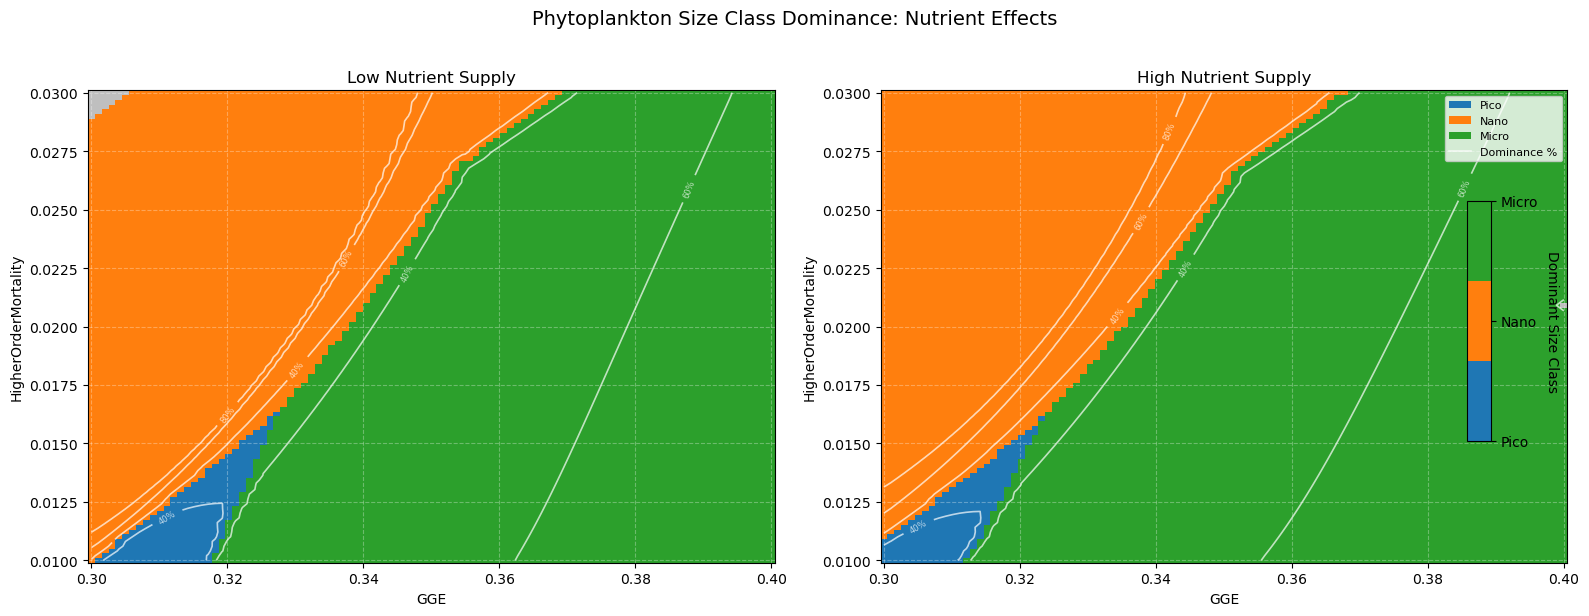

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter

def plot_size_dominance(ivp_results, ax=None, title='', show_colorbar=True, show_legend=True):
    """
    Plot which phytoplankton size class dominates across parameter space
    with contours showing strength of dominance within each region
    """
    # Get seaborn's default color palette (matches boxplot colors)
    palette = sns.color_palette()
    colors = [palette[0], palette[1], palette[2]]  # Blue, Orange, Green
    
    # Create axis if not provided
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    # Extract last 1000 days of phytoplankton biomass
    phyto_last1000 = ivp_results['Phytoplankton__biomass'].isel(time=slice(-1000, None))
    
    # Calculate mean biomass for each size class
    phyto_mean = phyto_last1000.mean(dim='time')
    
    # Get coordinate names - filter out standard ones
    coord_names = [c for c in ivp_results.coords.keys() 
                   if c not in ['time', 'phyto', 'zoo', 'clock', 'full']]
    
    # Assume first two non-standard coordinates are our parameter dimensions
    if len(coord_names) >= 2:
        x_coord = coord_names[0]
        y_coord = coord_names[1]
    else:
        raise ValueError(f"Could not identify parameter coordinates. Found: {coord_names}")
    
    print(f"Using coordinates: x={x_coord}, y={y_coord}")
    
    # Find dominant size class and dominance strength at each grid point
    dominant_class = np.full((len(ivp_results[x_coord]), 
                              len(ivp_results[y_coord])), 
                             np.nan)
    
    # Store dominance strength for each specific class
    pico_dominance = np.full_like(dominant_class, np.nan)
    nano_dominance = np.full_like(dominant_class, np.nan)
    micro_dominance = np.full_like(dominant_class, np.nan)
    
    for i in range(len(ivp_results[x_coord])):
        for j in range(len(ivp_results[y_coord])):
            biomass_values = phyto_mean[i, j, :].values
            if not np.all(np.isnan(biomass_values)):
                # Find dominant class
                dominant_idx = np.nanargmax(biomass_values)
                dominant_class[i, j] = dominant_idx
                
                # Calculate dominance strength
                total = np.nansum(biomass_values)
                if total > 0:
                    dominance_value = biomass_values[dominant_idx] / total
                    
                    # Store in appropriate class-specific array
                    if dominant_idx == 0:
                        pico_dominance[i, j] = dominance_value
                    elif dominant_idx == 1:
                        nano_dominance[i, j] = dominance_value
                    elif dominant_idx == 2:
                        micro_dominance[i, j] = dominance_value
    
    # Create custom colormap with seaborn colors
    cmap = ListedColormap(colors)
    cmap.set_bad(color='grey', alpha=0.5)
    
    # Plot dominance map
    X, Y = np.meshgrid(ivp_results[x_coord].values, 
                       ivp_results[y_coord].values)
    
    # Mask NaN values
    dominant_masked = np.ma.masked_invalid(dominant_class.T)
    
    im = ax.pcolormesh(
        X, Y, dominant_masked,
        cmap=cmap,
        vmin=0, vmax=2,
        shading='nearest'
    )
    
    # Add contours for dominance strength
    contour_levels = [0.4, 0.6, 0.8]  # Simplified levels
    sigma = 0.5
    
    # Plot contours for each size class separately
    for idx, dom_field in enumerate([pico_dominance, nano_dominance, micro_dominance]):
        if np.all(np.isnan(dom_field)):
            continue
            
        # Apply light smoothing
        dom_field_smooth = dom_field.copy()
        valid_mask = ~np.isnan(dom_field)
        if np.any(valid_mask):
            dom_filled = np.where(np.isnan(dom_field), 0, dom_field)
            dom_smooth = gaussian_filter(dom_filled, sigma=sigma)
            dom_field_smooth = np.where(valid_mask, dom_smooth, np.nan)
        
        # Mask invalid values for contour
        dom_masked = np.ma.masked_invalid(dom_field_smooth.T)
        
        if np.any(~np.isnan(dom_field_smooth)):
            try:
                contours = ax.contour(
                    X, Y, dom_masked,
                    levels=contour_levels,
                    colors='white',
                    linewidths=1.2,
                    alpha=0.7
                )
                ax.clabel(contours, inline=True, fontsize=6, 
                         fmt=lambda x: f'{int(x*100)}%')
            except:
                pass
    
    # Set labels - clean up the coordinate names
    x_label = x_coord.split('__')[0].replace('_', ' ')
    y_label = y_coord.split('__')[0].replace('_', ' ')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, linestyle='--', color='white')
    
    return im

# Create the two-panel plot for Low vs High Nutrients
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Low Nutrients
im1 = plot_size_dominance(
    ivp_result_lowNuts_HOMvsGGE, 
    ax=axes[0], 
    title='Low Nutrient Supply',
    show_colorbar=False,
    show_legend=False
)

# Panel 2: High Nutrients  
im2 = plot_size_dominance(
    ivp_result_highNuts_HOMvsGGE, 
    ax=axes[1], 
    title='High Nutrient Supply',
    show_colorbar=False,
    show_legend=False
)

# Add single colorbar for both panels
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
cbar = fig.colorbar(im1, cax=cbar_ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Pico', 'Nano', 'Micro'])
cbar.set_label('Dominant Size Class', rotation=270, labelpad=15)

# Add overall title
fig.suptitle('Phytoplankton Size Class Dominance: Nutrient Effects', fontsize=14, y=1.02)

# Add legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor=sns.color_palette()[0], label='Pico'),
    Patch(facecolor=sns.color_palette()[1], label='Nano'),
    Patch(facecolor=sns.color_palette()[2], label='Micro'),
    Line2D([0], [0], color='white', linewidth=1.2, alpha=0.7, 
           label='Dominance %')
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()

for i, ax in enumerate(axes):
    # Check if the axis contains actual data (i.e., not an error/blank plot)
    if not all_images or i >= len(all_images):
        continue
        
    # Get the coordinates used for the current plot's axes from the plotter instance
    # We must re-instantiate the plotter to get its calculated coordinates (x_coord, y_coord)
    # since we cannot access them easily from the previous loop's scope.
    # NOTE: This is slightly inefficient but necessary for keeping the logic OUTSIDE the class.
    try:
        current_plotter = PhytoplanktonPlotter(plot_data[i][0])
    except:
        continue # Skip if the data failed to initialize
        
    x_key = _get_param_key(current_plotter.x_coord)
    y_key = _get_param_key(current_plotter.y_coord)
    
    if x_key and y_key:
        x_values = [p[x_key] for p in SCENARIO_POINTS]
        y_values = [p[y_key] for p in SCENARIO_POINTS]
        labels = [p['label'] for p in SCENARIO_POINTS]

        # Scatter plot the points
        ax.scatter(x_values, y_values,
                   s=30,             # Smaller size for 6-panel plot
                   color='k',
                   marker='o',
                   edgecolor='w',
                   linewidth=1.0,
                   zorder=10
                  )

        # Add small labels next to the points
        for x, y, label in zip(x_values, y_values, labels):
            ax.annotate(label, (x, y),
                        textcoords="offset points",
                        xytext=(3, 3),    # Small offset
                        ha='left',
                        fontsize=6,
                        color='k',
                        zorder=10
                       )
                       
# Add scenario point to the main legend
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k', 
           markeredgecolor='w', markersize=5, label='Scenario Runs', linewidth=0) 
)

# Re-apply the legend with the new elements
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.91, 0.95),
           fontsize=8, title='Size Classes')
plt.show()

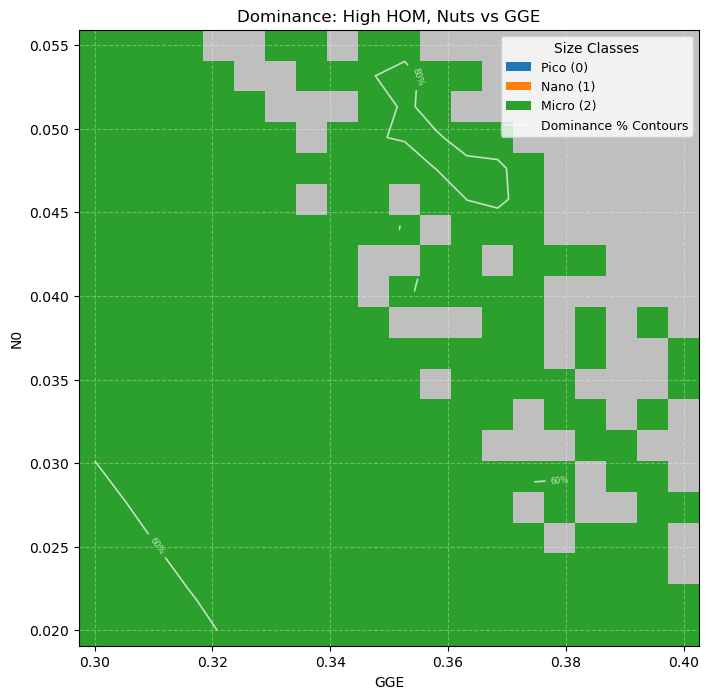

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 2. Initialize the Plotter class with your data
plotter = PhytoplanktonPlotter(ivp_result_highHOM_NutsvsGGE)

# 3. Call the plot method
im = plotter.plot(ax=ax, title='Dominance: High HOM, Nuts vs GGE')

# 4. Add Colorbar and Legend (Specific to this single plot)


# Add Legend
legend_elements = [
    Patch(facecolor=COLORS[0], label='Pico (0)'),
    Patch(facecolor=COLORS[1], label='Nano (1)'),
    Patch(facecolor=COLORS[2], label='Micro (2)'),
    Line2D([0], [0], color='white', linewidth=1.2, alpha=0.7,
           label='Dominance % Contours')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, title='Size Classes')

#plt.tight_layout()
plt.show()